# Determining electric conductivity $\sigma$ and magnetic field $B$

### Imports

In [599]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


from python_utils.utils import load_object

from python_utils.yz_slice_utils import find_closest_coordinate_index

from python_utils.plotting import plot_timeseries
from python_utils.plotting import plot_heatmap

from python_utils.data_processing import print_yz_slice_example_from_parsed_data

from python_utils.sigma_and_b_estimation import calc_conductivity_with_z

### General Args

In [600]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 1000

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1  # According to the results here.
B_z = -1  # According to the results here.

### Load Data

In [601]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [602]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
print_yz_slice_example_from_parsed_data(gradF_data)

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 49, n_z (grid width) = 49, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.         0.         0.        -0.2709205  0.         0.
 -0.0004302  0.290587 ]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.755902e-01  0.000000e+00
  4.372047e-01 -4.302696e-04  2.858409e-01]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.637546e-01 -3.491415e+00
  0.000000e+00 -4.098474e-04  3.136015e-01]
  (y=-0.99, z=-0.99): [-3.760981e+00  4.328748e-02 -1.042420e-01 -2.076186e-01  6.084429e-03
  2.005159e-01 -4.101349e-04  3.114591e-01]

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 49, n_z (grid width) = 49, n_v (number of variables) = 3
Labels:
['dfdx', 'dfdy', 'dfdz']
Preview of the first snapshot (first 2 y, first 2 z

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

## Ohm's Law in z-coord

### Find 0 Entries

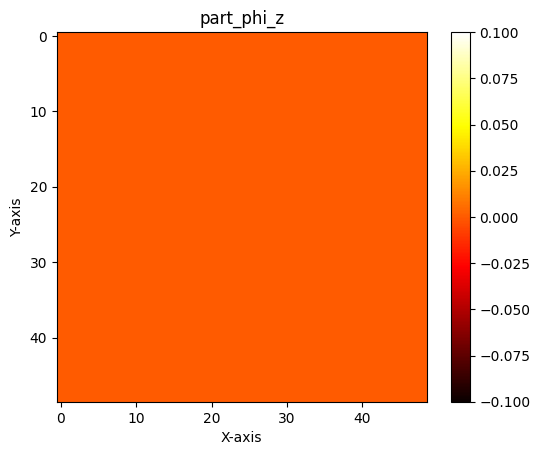

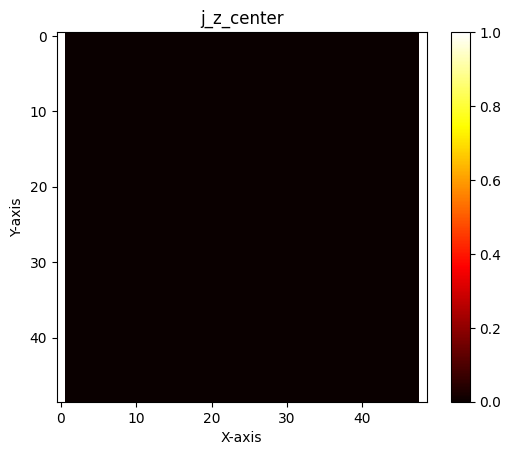

In [603]:
part_phi_z = gradF_data['timeseries'][
    :,
    :,
    :,
    gradF_data['labels'].index('dfdz'),
]
plot_heatmap(
    np.all(
        part_phi_z == 0,
        axis=0,
        ),
    title='part_phi_z',
    )

j_z_center = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('jz'),
]
plot_heatmap(
    np.all(
        j_z_center == 0,
        axis=0,
        ),
    title='j_z_center',
    )

### Calculate Sigma

mean(mean(sigma_est_ts)) = -1.0000217761927164
mean(3 * std(sigma_est_ts)) = 0.11898800048264076
median(median(sigma_est_ts)) = -1.0000046113926104


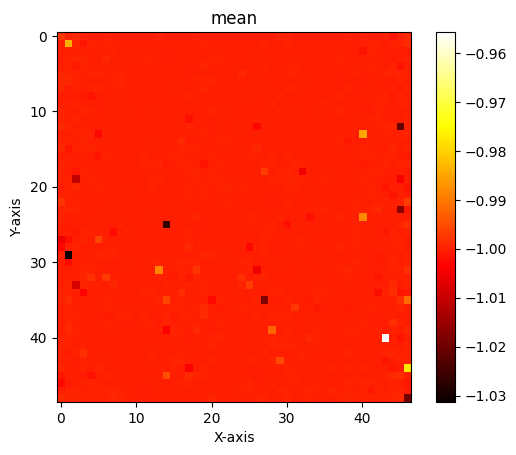

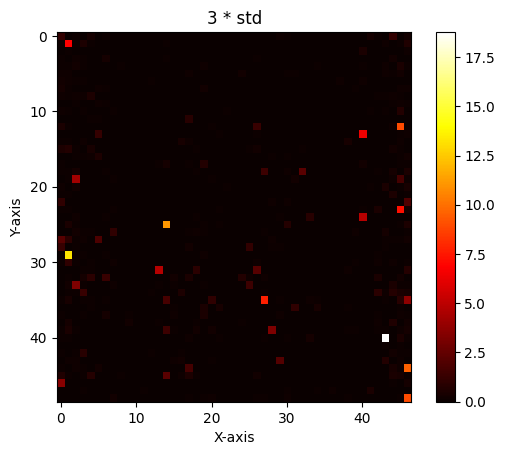

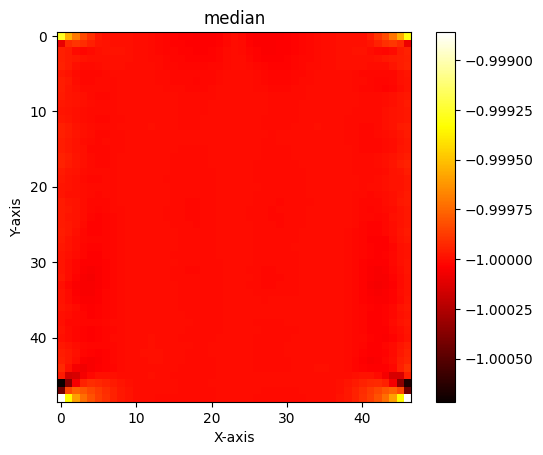

In [604]:
sigma_est_ts = calc_conductivity_with_z(
        partial_phi_data=gradF_data,
        partial_phi_label='dfdz',
        current_data=fld_data,
        current_label='jz',
        )
sigma_est_ts = sigma_est_ts[:, :, 1:-1]  # Exclude boundaries with 0 entries.

mean = np.mean(
        sigma_est_ts,
        axis=0,
        )
std = np.std(
        sigma_est_ts,
        axis=0,
        )
median = np.median(
        sigma_est_ts,
        axis=0,
        )

print(f"mean(mean(sigma_est_ts)) = {np.mean(mean)}")
print(f"mean(3 * std(sigma_est_ts)) = {np.mean(3 * std)}")
print(f"median(median(sigma_est_ts)) = {np.median(median)}")

plot_heatmap(
    mean,
    title='mean'
    )
plot_heatmap(
    3*std,
    title='3 * std'
    )
plot_heatmap(
    median,
    title='median'
    )

## Ohm's Law in x-coord

### Find 0 Entries

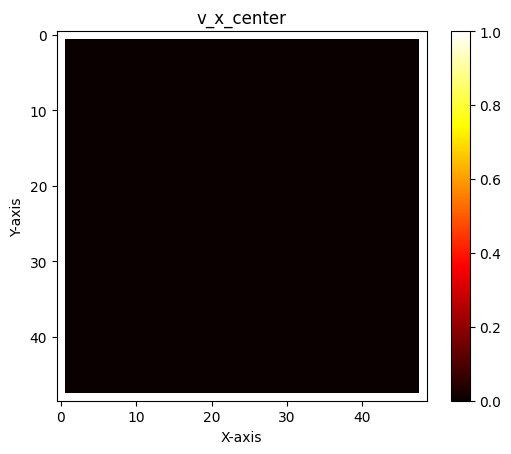

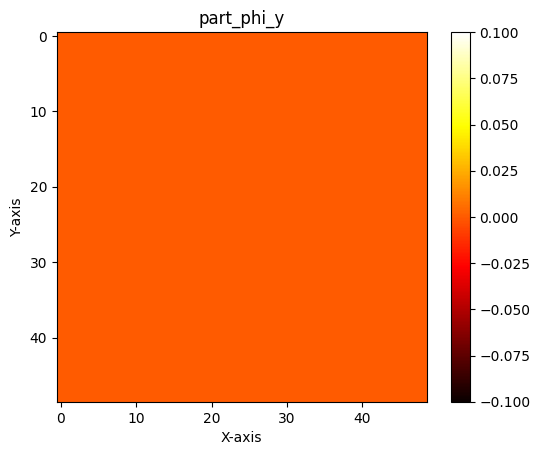

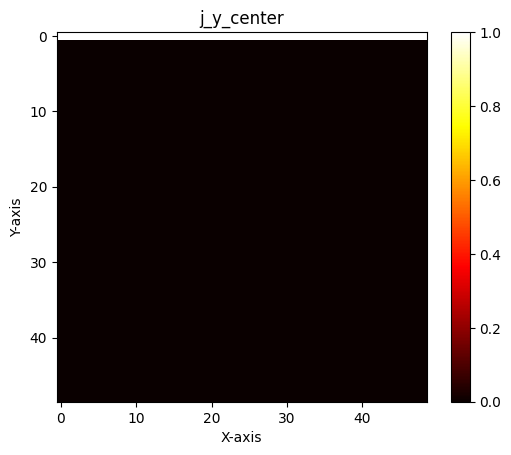

In [605]:
v_x_center = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('vx'),
    ]
plot_heatmap(
    np.all(
        v_x_center == 0,
        axis=0,
        ),
    title='v_x_center',
    )
v_x_center = v_x_center[:, 1:-1, 1:-1]

part_phi_y = gradF_data['timeseries'][
    :,
    :,
    :,
    gradF_data['labels'].index('dfdy'),
    ]
plot_heatmap(
    np.all(
        part_phi_y == 0,
        axis=0,
        ),
    title='part_phi_y',
    )
part_phi_y = part_phi_y[:, 1:-1, 1:-1]

j_y_center = fld_data['timeseries'][
    :,
    :,
    :,
    fld_data['labels'].index('jy'),
    ]
plot_heatmap(
    np.all(
        j_y_center == 0,
        axis=0,
        ),
    title='j_y_center',
    )
j_y_center = j_y_center[:, 1:-1, 1:-1]

### Estimate $B_z$

In [606]:
B_z_est = np.divide(
    part_phi_y - j_y_center / sigma,
    v_x_center,
    )

##### Mean

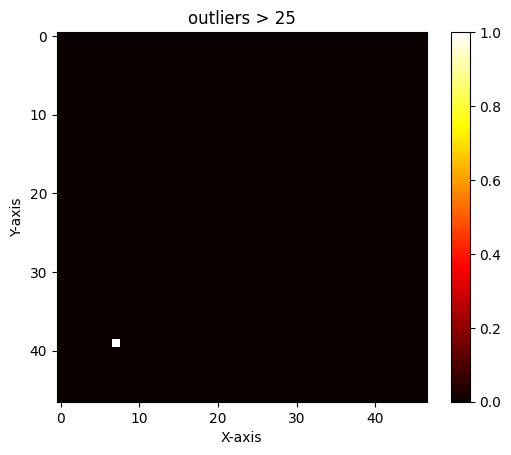

mean(mean(B_z_est) | mean(B_z_est) < 25) = -1.0005376557322523


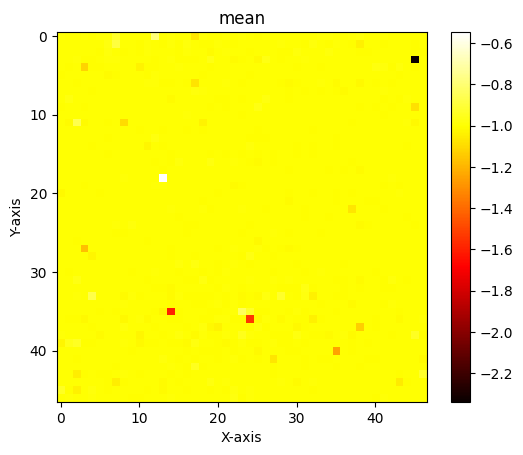

In [607]:
mean = np.mean(
    B_z_est,
    axis=0,
    )

plot_heatmap(
    mean > 25,
    title='outliers > 25'
    )
print(f"mean(mean(B_z_est) | mean(B_z_est) < 25) = {np.mean(mean[mean < 25])}")


# Adjust outlier for better plot.
mean_wo_outlier = mean.copy()
mean_wo_outlier[mean_wo_outlier > 25] = np.median(mean_wo_outlier)

plot_heatmap(
    mean_wo_outlier,
    title='mean'
    )

##### 3-Std-Dev

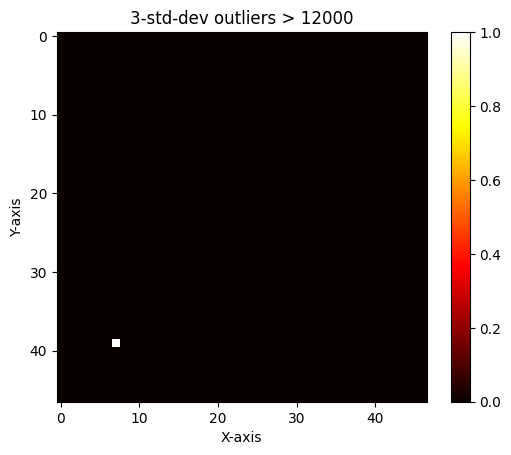

mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = 2.098521502962123


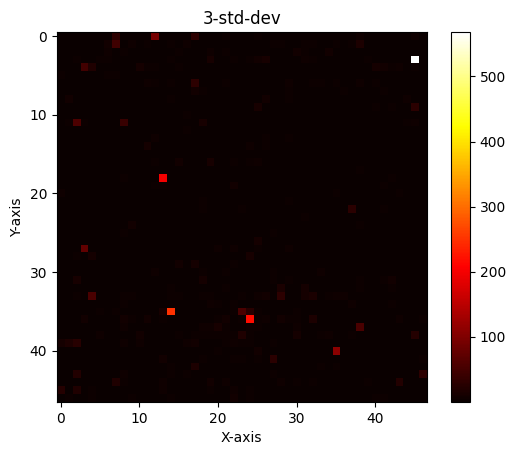

In [608]:
std = np.std(
    B_z_est,
    axis=0,
    )
std_3 = 3 * std

plot_heatmap(
    std_3 > 12000,
    title='3-std-dev outliers > 12000'
    )
print(f"mean(3 * std(B_z_est) | 3 * std(B_z_est) < 12000) = {np.mean(std_3[std_3 < 12000])}")

# Adjust outlier for better plot.
std_3_wo_outlier = std_3.copy()
std_3_wo_outlier[std_3_wo_outlier > 12000] = np.median(std_3_wo_outlier)

plot_heatmap(
    std_3_wo_outlier,
    title='3-std-dev'
    )

##### Median

median(median(B_z_est)) = -0.9998806212571416


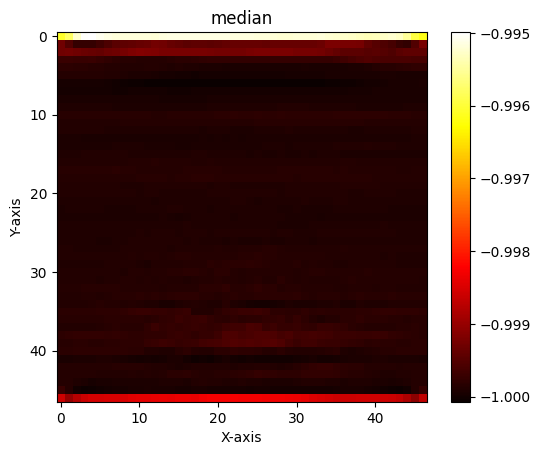

In [609]:
median = np.median(
    B_z_est,
    axis=0,
    )

print(f"median(median(B_z_est)) = {np.median(median)}")
plot_heatmap(
    median,
    title='median'
    )

### Calculate Sigma

##### Epsilon on 0 Divisors

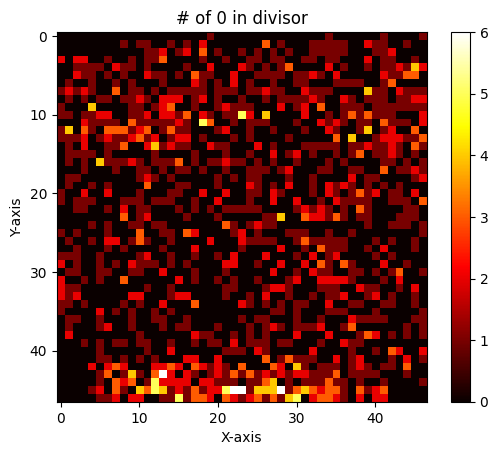

In [610]:
divisor = part_phi_y - v_x_center * B_z
# plot_heatmap(
#     np.any(
#         divisor == 0,
#         axis=0,
#         ),
#     title='divisor',
#     )
plot_heatmap(
    np.sum(divisor == 0, axis=0),
    title='# of 0 in divisor',
    )
epsilon = 1e-10
divisor_plus_eps = divisor.copy()
divisor_plus_eps[divisor_plus_eps == 0] += epsilon

##### Main

-0.8039002622821557
mean(mean(sigma_est_ts)) = -0.8039002622821557
mean(3 * std(sigma_est_ts)) = 434.68739633652206
median(median(sigma_est_ts)) = -0.9072303921568442


TypeError: Invalid shape () for image data

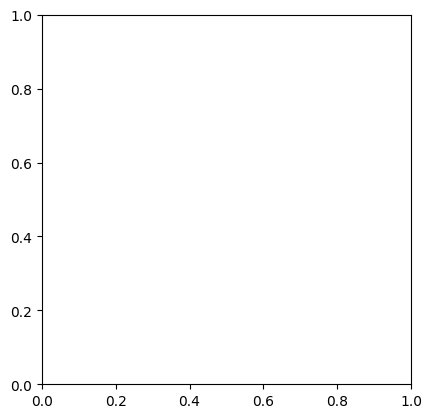

In [ ]:
# TODO
sigma_est_ts = np.divide(
    j_y_center,
    divisor_plus_eps,
    )

mean = np.mean(
        sigma_est_ts[divisor != 0],
        axis=0,
        )
std = np.std(
        sigma_est_ts[divisor != 0],
        axis=0,
        )
median = np.median(
        sigma_est_ts[divisor != 0],
        axis=0,
        )

print(f"mean(mean(sigma_est_ts)) = {np.mean(mean)}")
print(f"mean(3 * std(sigma_est_ts)) = {np.mean(3 * std)}")
print(f"median(median(sigma_est_ts)) = {np.median(median)}")

plot_heatmap(
    mean,
    title='mean'
    )
plot_heatmap(
    3*std,
    title='3 * std'
    )
plot_heatmap(
    median,
    title='median'
    )